EVA VWLS method for AMAS Project, based on https://doi.org/10.1016/j.hydroa.2018.100012

original code by peter resch, 12.3.2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
import os

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

save_figures = False

## #read in file

In [2]:
print(os.getcwd())
#os.chdir("code/VWLS/")

/home/peter/AMAS_PROJECT/Code


In [3]:
"""dataset location"""
filename="gauss-mu=5,sigma=2.0,N=e9,cutoff=4sig.csv"
directory = "data"
filepath = directory+ "/" + filename
print(f"Filepath: {filepath}")

Filepath: data/gauss-mu=5,sigma=2.0,N=e9,cutoff=4sig.csv


In [4]:
"""read the values from the text file"""
extreme_values_from_file = []
with open(filepath, "r") as f:
    for line in f:
        extreme_values_from_file.append(float(line.strip()))

print(f"Number of extreme values: {len(extreme_values_from_file)}")

Number of extreme values: 33402


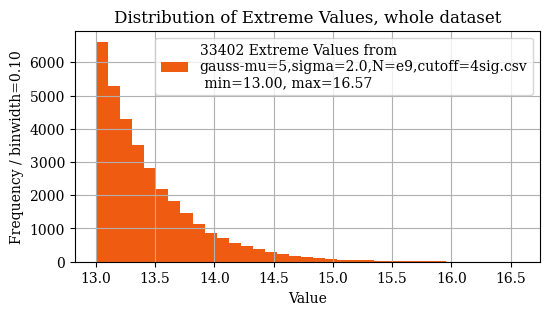

In [5]:
"""illustrating the distribution of the extreme values with a histogram"""
min_value = min(extreme_values_from_file)
max_value = max(extreme_values_from_file)
#n_bins = 50
bin_width = 0.1
n_bins = int((max_value - min_value) / bin_width)

plt.hist(extreme_values_from_file, bins=n_bins, alpha=1, color=my_cmap(0.8),label=f"{len(extreme_values_from_file)} Extreme Values from\n{filename}\n min={min_value:.2f}, max={max_value:.2f}")
plt.xlabel("Value")
plt.ylabel(f"Frequency / binwidth={bin_width:.2f}")
plt.title("Distribution of Extreme Values, whole dataset")
plt.grid()
plt.legend()
plt.show()

if save_figures:
    plt.savefig(f"{directory}/histogram_extreme_values_{filename}.png")

## #Selecting Distribution and estimating start parameters

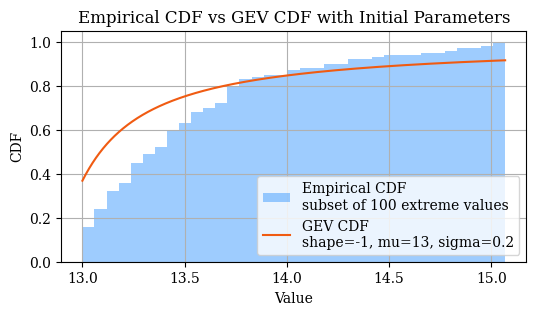

In [37]:
"""define starting parameters for fitting the GEV distribution"""
from tabnanny import verbose


shape_param = -1
mu_param = 13
sigma_param = 0.2

def gev_cdf(xi_array, shape_param, mu_param, sigma_param):
    cdf_value=stats.genextreme.cdf(x=xi_array, c=shape_param, loc=mu_param, scale=sigma_param)
    if verbose:
        print(f"GEV CDF at xi={xi_array:.4f}: {cdf_value:.8e}")
    return cdf_value


"""select a subset of the extreme values for fitting the GEV distribution"""
subset_size = 100
x_subset=extreme_values_from_file[:subset_size]


"""plotting the empirical CDF of the subset of extreme values and the GEV CDF with the initial parameters"""
xi_values_plot = np.linspace(min(x_subset), max(x_subset), 1000)
gev_cdf_values = gev_cdf(xi_values_plot, shape_param, mu_param, sigma_param)

plt.hist(x_subset, bins=n_bins, density=True, alpha=0.5, color=my_cmap(0.2), label=f"Empirical CDF\nsubset of {subset_size} extreme values",cumulative=True)
plt.plot(xi_values_plot, gev_cdf_values, label=f"GEV CDF\nshape={shape_param}, mu={mu_param}, sigma={sigma_param}", color=my_cmap(0.8))
plt.xlabel("Value")
plt.ylabel("CDF")
plt.title("Empirical CDF vs GEV CDF with Initial Parameters")
plt.grid()
plt.legend()
plt.show()
if save_figures:
    plt.savefig(f"{directory}/empirical_cdf_vs_gev_cdf_initial_{filename}.png")

## #Weibull Plotting Positions

In [46]:
"""Ranking the subset of data points"""
x_m = np.sort(x_subset)
m_array = np.arange(1, subset_size + 1)  # ranks from 1 to subset_size


"""define Weibull plotting positions"""
def weibull_p_m(rank_m, n):
    """ rank_m >= 1
        n = number of data points in the subset"""
    p_m=rank_m / (n + 1)
    #print(f"P(m={rank_m},N={n}) = {p_m:.8f}")
    return p_m


"""best estimate for xi_m in the given search range"""
def first_estimate_xi(rank_m,search_min,search_max):
    """returns  -1 if search_min is too high
                +1 if search_max is too low
                proposed xi_m and stepsize if the search range contains the solution"""
    if rank_m < 1 or rank_m > subset_size:
        raise ValueError(f"rank_m must be between 1 and {subset_size}, got {rank_m}.")
    
    p_m=weibull_p_m(rank_m, subset_size)
    f_min = gev_cdf(search_min, shape_param, mu_param, sigma_param)
    f_max = gev_cdf(search_max, shape_param, mu_param, sigma_param)
    #print(f_max)
    if f_min > p_m:
        print(f"GEV CDF at search_min={search_min:.4f} is {f_min}: greater than p_m={p_m:.6f} for rank {rank_m}. Consider decreasing search_min.")
        return -1
    elif f_max < p_m:
        print(f"GEV CDF at search_max={search_max:.4f} is {f_max}: less than p_m={p_m:.6f} for rank {rank_m}. Consider increasing search_max.")
        return +1
    
    else:
        diff = (search_max - search_min)
        if diff <= 0:
            print(f"rank_m={rank_m}: diff={diff}")
            raise ValueError("search_max must be greater than search_min.")
        
        steps=100
        stepsize = diff / steps
        xi_proposal = np.arange(search_min, search_max, stepsize)

        for m in range(steps):
            gev_cdf_value = gev_cdf(xi_proposal[m], shape_param, mu_param, sigma_param)
            #print(f"xi_proposal: {xi_proposal[m]:.4f}, GEV CDF: {gev_cdf_value:.6f}, p_m: {p_m:.6f}")
            if gev_cdf_value >= p_m:
                #print(f"Found corresponding xi_m in the proposal array")
                return xi_proposal[m],stepsize
        return search_max,stepsize# between last proposal and search_max, the solution must lie



"""best estimate for xi_m in the search range with a given resolution of decimal places """
def best_estimate_xi_with_resolution(rank_m,search_min,search_max,resolution=0.01):
    while True:
        result = first_estimate_xi(rank_m, search_min, search_max)
        print(f"in best_estimate loop: first_estimate result={result}")
        if result == -1:
            # shift range downward
            range = search_max - search_min
            search_min -= range
            search_max -= range
            continue

        if result == 1:
            # shift range upward
            range = search_max - search_min
            search_min += range
            search_max += range
            continue

        # Here result is guaranteed to be a tuple (xi_propose, step_size)
        xi_propose, step_size = result

        if step_size <= resolution:
            return xi_propose

        # refine around candidate
        search_max = xi_propose
        search_min = xi_propose - step_size

In [49]:

#testing
rank_m =3
result = first_estimate_xi(rank_m, 0, 13)
if result == (1 or -1):
    raise ValueError(f"best_estimate_xi returned None for rank_m={rank_m} in range [{x_m[0]:.4f}, {x_m[-1]:.4f}]")
xi_value, xi_in_range = result

print(f"cdf(m={rank_m}) = {gev_cdf(xi_value, shape_param, mu_param, sigma_param):.8f}")
print(f"xi(m={rank_m}) = {xi_value:.4f}")
print(f"P(m={rank_m},N={subset_size}) = {weibull_p_m(rank_m, subset_size):.8f}")
print(f"x(m={rank_m}) = {x_m[rank_m]:.4f}")
print(f"Difference between GEV CDF at xi_m and Weibull plotting position: {gev_cdf(xi_value, shape_param, mu_param, sigma_param) - weibull_p_m(rank_m, subset_size):.8f}")

cdf(m=3) = 0.05743262
xi(m=3) = 12.8700
P(m=3,N=100) = 0.02970297
x(m=3) = 13.0112
Difference between GEV CDF at xi_m and Weibull plotting position: 0.02772965


In [50]:
best_estimate_xi_with_resolution(rank_m, 13, 14, resolution=0.001)

GEV CDF at search_min=13.0000 is 0.36787944117144233: greater than p_m=0.029703 for rank 3. Consider decreasing search_min.
in best_estimate loop: first_estimate result=-1
in best_estimate loop: first_estimate result=(np.float64(12.859999999999982), 0.01)
in best_estimate loop: first_estimate result=(np.float64(12.856899999999966), np.float64(9.999999999999786e-05))


np.float64(12.856899999999966)

In [51]:
def round_partial(value, resolution):
    return np.round(value / resolution) * resolution


def find_all_xi_m(ranked_m,estimate_search_min,estimate_search_max,res=0.0001):
    xi_m=np.zeros_like(ranked_m, dtype=float)
    for i,rank in enumerate(ranked_m):#rank in [1, subset_size]
        #print(f"in find_all_xi_m: rank{rank}")
        if i==0:
            xi_m[0] = round_partial(best_estimate_xi_with_resolution(1, estimate_search_min, estimate_search_max,res),res)
            continue
        estimate=best_estimate_xi_with_resolution(rank, xi_m[i-1], xi_m[i-1]+2,res)
        xi_m[i] = round_partial(estimate,res)

        print(f"Calculated xi_m for rank {rank}/{subset_size}", end="\r")
    
    xi_m = np.array(xi_m)
    return xi_m

In [52]:
"""calculating plotting positions and corresponding xi_m for the ranked data points"""
ranks_m = np.arange(1, subset_size + 1)
p_m = weibull_p_m(ranks_m, n=subset_size)

xi_m = find_all_xi_m(ranks_m,10,15,0.001)

in best_estimate loop: first_estimate result=(np.float64(12.85000000000004), 0.05)
in best_estimate loop: first_estimate result=(np.float64(12.843500000000093), np.float64(0.0005000000000000071))
in best_estimate loop: first_estimate result=(np.float64(12.863999999999999), np.float64(0.02))
in best_estimate loop: first_estimate result=(np.float64(12.850999999999983), np.float64(0.00019999999999999573))
in best_estimate loop: first_estimate result=(np.float64(12.871), np.float64(0.02))
in best_estimate loop: first_estimate result=(np.float64(12.856999999999987), np.float64(0.00019999999999999573))
in best_estimate loop: first_estimate result=(np.float64(12.877), np.float64(0.02))
in best_estimate loop: first_estimate result=(np.float64(12.86199999999999), np.float64(0.00019999999999999573))
in best_estimate loop: first_estimate result=(np.float64(12.882), np.float64(0.02))
in best_estimate loop: first_estimate result=(np.float64(12.86659999999999), np.float64(0.00019999999999999573))
in

in best_estimate loop: first_estimate result=(np.float64(12.893999999999991), np.float64(0.00019999999999999573))
in best_estimate loop: first_estimate result=(np.float64(12.914), np.float64(0.02))
in best_estimate loop: first_estimate result=(np.float64(12.897599999999992), np.float64(0.00019999999999999573))
in best_estimate loop: first_estimate result=(np.float64(12.918), np.float64(0.02))
in best_estimate loop: first_estimate result=(np.float64(12.901399999999992), np.float64(0.00019999999999999573))
in best_estimate loop: first_estimate result=(np.float64(12.921), np.float64(0.02))
in best_estimate loop: first_estimate result=(np.float64(12.90499999999999), np.float64(0.00019999999999999573))
in best_estimate loop: first_estimate result=(np.float64(12.925), np.float64(0.02))
in best_estimate loop: first_estimate result=(np.float64(12.908599999999993), np.float64(0.00019999999999999573))
in best_estimate loop: first_estimate result=(np.float64(12.929), np.float64(0.02))
in best_est

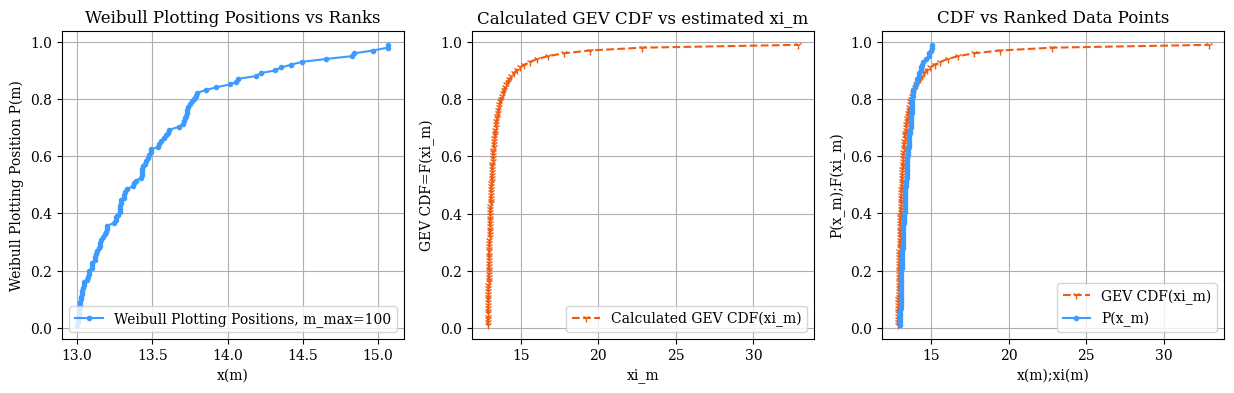

In [53]:
"""Illustrating the ranked data points and their Weibull plotting positions"""
fig,[ax_weibull,ax_cdf,ax_combi]=plt.subplots(1,3,figsize=(15,4))

ax_weibull.plot(x_m, p_m, color=my_cmap(0.2), label=f"Weibull Plotting Positions, m_max={subset_size}", marker='.', linestyle='-')
ax_weibull.set_xlabel("x(m)")
ax_weibull.set_ylabel("Weibull Plotting Position P(m)")
ax_weibull.set_title("Weibull Plotting Positions vs Ranks")
ax_weibull.grid()
ax_weibull.legend(loc="lower right")


ax_cdf.plot(xi_m,gev_cdf(xi_m,shape_param,mu_param,sigma_param), color=my_cmap(0.8), label="Calculated GEV CDF(xi_m)", marker=my_marker, linestyle='--')
ax_cdf.set_xlabel("xi_m")
ax_cdf.set_ylabel("GEV CDF=F(xi_m)")
ax_cdf.set_title("Calculated GEV CDF vs estimated xi_m")
ax_cdf.grid()
ax_cdf.legend(loc="lower right")

ax_combi.plot(xi_m,gev_cdf(xi_m,shape_param,mu_param,sigma_param), color=my_cmap(0.8), label="GEV CDF(xi_m)", marker=my_marker, linestyle='--')
ax_combi.plot(x_m, p_m, color=my_cmap(0.2), label=f"P(x_m)", marker='.', linestyle='-')
ax_combi.set_xlabel("x(m);xi(m)")
ax_combi.set_ylabel("P(x_m);F(xi_m)")
ax_combi.set_title("CDF vs Ranked Data Points")
ax_combi.grid()
ax_combi.legend(loc="lower right")

if save_figures:
     plt.savefig(f"{directory}/xi_m_and_weibull_plotting_positions_{filename}.png")


## #Weighing and fitting - functions

In [ ]:
def gev_pdf(xi_array, shape_param, mu_param, sigma_param):
    pdf_value=stats.genextreme.pdf(x=xi_array, c=shape_param, loc=mu_param, scale=sigma_param)
    if verbose:
        print(f"GEV PDF at xi={xi_array:.4f}: {pdf_value:.8e}")
    return pdf_value


def g_fct(rank,n_data_points):
    g=scipy.special.comb(N=n_data_points, k=rank, exact=True)/rank
    if verbose:
        print(f"g(rank={rank}, n_data_points={n_data_points}): {g:.8e}")
    return g


def pdf_of_xi_m(rank,n_data_points, xi_m):
    g_value=g_fct(rank, n_data_points)
    gev_cdf_value = gev_cdf(xi_m, shape_param, mu_param, sigma_param)
    gev_pdf_value = gev_pdf(xi_m, shape_param, mu_param, sigma_param)
    f_m=g_value * gev_cdf_value**(rank-1) * (1-gev_cdf_value)**(n_data_points-rank)*gev_pdf_value
    if verbose:
        print(f"pdf_of_xi_m for rank {rank} at xi_m={xi_m:.4f}: {f_m:.8e}")
    return f_m


def xi_m_mean(rank,n_data_points):
    integral = scipy.integrate.quad(lambda xi: xi * pdf_of_xi_m(rank,n_data_points, xi), -np.inf, np.inf)
    if verbose:
        print(f"xi_mean for rank {rank}: {integral}")
    return integral[0]

    
def xi_m_variance(rank,n_data_points):
    mean_xi_m=xi_m_mean(rank,n_data_points)
    integral = scipy.integrate.quad(lambda xi: (xi-mean_xi_m)**2 * pdf_of_xi_m(rank,n_data_points, xi), -np.inf, np.inf)
    if verbose:
        print(f"xi_variance for rank {rank}: {integral}")
    return integral[0]


def calculating_weights(rank):
    xi_m_variance_value=xi_m_variance(rank, subset_size)
    weight=1/xi_m_variance_value
    if verbose:
        print(f"Weight for rank {rank}: {weight}")
    return weight


def calculate_all_weights(rank_array):
    weights=np.zeros_like(rank_array, dtype=float)
    for i,rank in enumerate(rank_array):
        weights[i]=calculating_weights(rank)
        print(f"Calculated weight for rank {rank}/{subset_size}", end="\r")
    return weights


def sum_of_weights(weight_array):
    total_weight=np.sum(weight_array)
    print(f"Total weight: {total_weight}")
    return total_weight


def normalize_weigths(weight_array):
    sum=sum_of_weights(weight_array)
    print(f"normalized")
    return weight_array/sum


In [67]:
#test

verbose=True
rank_test=1
xi_1=xi_m[rank_test-1]

print(f"Testing the functions for rank {rank_test}, subset length={subset_size}")

#gev_cdf_1=gev_cdf(xi_1, shape_param, mu_param, sigma_param)
#gev_pdf_1=gev_pdf(xi_1, shape_param, mu_param, sigma_param)
#g_fct_1=g_fct(rank_test, subset_size)
#pdf_xi_1=pdf_of_xi_m(rank_test, subset_size, xi_1)
#xi_1_mean=xi_m_mean(rank_test, subset_size)
#xi_1_variance=xi_m_variance(rank_test, subset_size)
#weight_1=calculating_weights(rank_test)

Testing the functions for rank 1, subset length=100


## #Reject data - function

In [ ]:
def reject_test(xi_array, b_parameter=0.001):
    """
    Tests wether the first rank of the array should be rejected

    Raises Error, if the array is too small

    Pararmeters
    -----------
    xi_array (np.array): Array of ranked xi values.

    b_parameter (float): Selected rejection test parameter.

    
    Returns
    -------
    bool
        True: rank_k (k=1) should be rejected.

        False: if it should be kept.
    """

    if len(xi_array)<5:
        raise ValueError("xi_array must have at least 5 elements to perform the rejection test. Data is unreliable.")
    
    xi_k=xi_array[0]
    xi_k_plus_1=xi_array[1]
    xi_n=xi_array[-1]

    test_value=(xi_k_plus_1-xi_k)/(xi_n-xi_k)
    if test_value<b_parameter:
        #reject rank_k
        return True
    else:
        #keep rank_k
        return False
    
    
def rejection_procedure(xi_array, b_parameter=0.001):
    """
    goes through the array and tests, if ranks should be rejected

    Returns:
        array(bool): mask the rejected data - False=Rejected
    """

    rejection_mask=np.full_like(xi_array, True, dtype=bool)
    for k in range(1, len(xi_array)-1):
        if reject_test(xi_array, b_parameter):
            rejection_mask[k] = False
    return rejection_mask


rejection_procedure

## #Fitting process